# Phase 7 — Flagger Calibration

The Phase 6 notebook trained a logistic regression and reported ROC AUC and Brier. Both are summary scores. This notebook breaks down *how trustworthy* the probabilities are and picks a deployable threshold that's framed in operational terms (reviewer budget) rather than as the abstract F1-optimum.

**What "calibration" means**: when the model says `prob_wrong = 0.7`, is that line *actually* wrong 70% of the time? A model can have great ROC AUC (it ranks wrong lines above correct ones) and still be miscalibrated (its numeric probabilities don't match real frequencies). Reviewers and downstream systems need calibrated numbers.

**What "reviewer budget" means**: in production we won't review every flagged line. A more useful question than "what threshold maximises F1?" is "if we can afford to review the top 30% of lines, what fraction of remaining errors do we catch?" That's the framing I use to pick the deployable threshold.

**Inputs**: same parquet as Phase 6 (`data/parquet_cache/iam_gw_pipeline.parquet`, 656 lines, 20 docs) and the trained bundle `models/flagger_v1.pkl`.

**Outputs**: reliability diagram, reviewer-budget curve, confusion matrices at chosen thresholds, and an updated `threshold` in the model bundle.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "parquet_cache" / "iam_gw_pipeline.parquet"
MODEL_PATH = PROJECT_ROOT / "models" / "flagger_v1.pkl"

FEATURE_NAMES = [
    "n_tokens", "mean_logprob", "min_logprob", "std_logprob",
    "length_normalized_logprob", "edit_distance_trocr_vs_corrected",
    "n_chars_changed", "frac_chars_changed", "llm_confidence",
    "line_height_px", "line_width_px",
]
TARGET = "is_still_wrong"

## 1. Load data and the trained model

In [2]:
df = pd.read_parquet(PARQUET)
bundle = joblib.load(MODEL_PATH)
print(f"data: {len(df)} rows, {df['doc_id'].nunique()} docs")
print(f"model trained on: {bundle['metrics']['n_train']} rows")
print(f"current threshold: {bundle['threshold']:.3f}")
print(f"current CV AUC: {bundle['metrics']['cv_auc']:.3f}")
print(f"current CV Brier: {bundle['metrics']['cv_brier']:.3f}")

data: 656 rows, 20 docs
model trained on: 656 rows
current threshold: 0.856
current CV AUC: 0.719
current CV Brier: 0.164


## 2. Reproduce out-of-fold predictions

We re-run the GroupKFold CV from Phase 6 to get out-of-fold predictions for each line. These are the predictions the calibration analysis sits on top of.

In [3]:
X = df[FEATURE_NAMES].fillna(0.0).values
y = df[TARGET].astype(int).values
groups = df["doc_id"].values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=0)),
])

cv_probs = cross_val_predict(
    pipe, X, y, groups=groups, cv=GroupKFold(n_splits=5),
    method="predict_proba", n_jobs=-1,
)[:, 1]

print(f"CV ROC AUC: {roc_auc_score(y, cv_probs):.3f}")
print(f"CV Brier  : {brier_score_loss(y, cv_probs):.3f}")

CV ROC AUC: 0.719
CV Brier  : 0.164


## 3. Reliability diagram

Bin predictions into deciles by predicted probability. For each bin, plot the **mean predicted probability** (x) against the **observed positive rate** (y). A perfectly calibrated model lies on the diagonal — when it says 0.7 it's wrong 70% of the time.

Anything above the diagonal: the model is *under-confident* (says lower than reality). Anything below: *over-confident*.

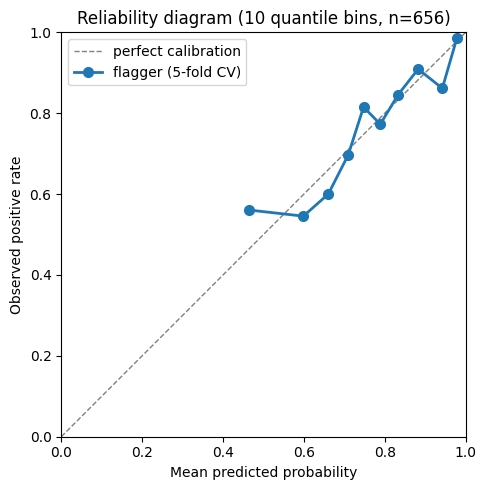

In [4]:
n_bins = 10
prob_true, prob_pred = calibration_curve(y, cv_probs, n_bins=n_bins, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="perfect calibration")
ax.plot(prob_pred, prob_true, "o-", color="C0", linewidth=2, markersize=7,
        label="flagger (5-fold CV)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.set_title(f"Reliability diagram ({n_bins} quantile bins, n=656)")
ax.legend(loc="upper left")
ax.set_aspect("equal")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**How to read this**: each marker is one decile of predictions. The x-coordinate is what the model said for that bin (e.g., "average prob 0.65"), the y-coordinate is what *actually* happened (e.g., "70% of those lines were truly wrong"). Markers near the diagonal = well-calibrated. Markers consistently above or below = systematic miscalibration that we'd want to fix with isotonic or sigmoid recalibration.

For a 656-row dataset this picture is going to be noisy at the tails (few samples per bin in low- and high-probability regions). The main quality check is whether the middle bins track the diagonal — if they do, the model's probabilities can be used directly for reviewer prioritisation.

## 4. Reviewer-budget framing

The actually-useful question for deployment: **if reviewers can afford to read X% of lines, what fraction of remaining errors do we catch?** This is the calibrated version of "pick a threshold."

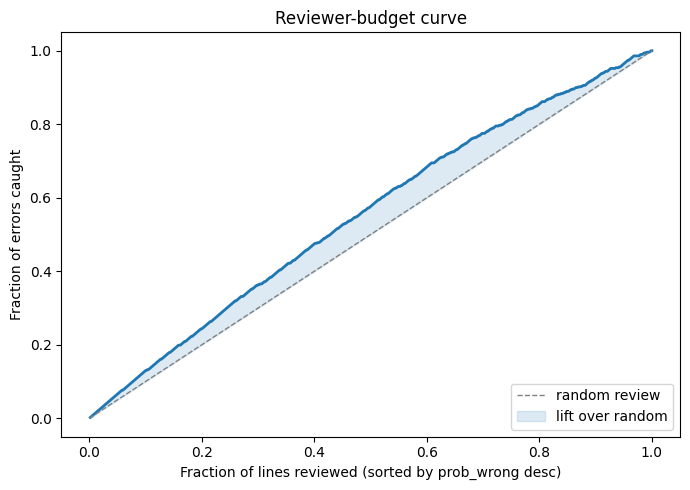

=== Operating points ===
  review %   errors caught   threshold
       10%          13.1%        0.962
       20%          24.5%        0.916
       30%          36.3%        0.856
       50%          57.6%        0.767
       75%          81.3%        0.659


In [5]:
# Sort lines by predicted prob descending; cumulative error-recall as we
# review more of the queue.
order = np.argsort(-cv_probs)
y_sorted = y[order]
probs_sorted = cv_probs[order]

n = len(y)
total_errors = y.sum()
cumulative_errors = np.cumsum(y_sorted)
review_fraction = (np.arange(1, n + 1)) / n
error_recall = cumulative_errors / total_errors

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(review_fraction, error_recall, color="C0", linewidth=2)
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="random review")
ax.fill_between(review_fraction, review_fraction, error_recall,
                where=(error_recall >= review_fraction),
                alpha=0.15, color="C0", label="lift over random")
ax.set_xlabel("Fraction of lines reviewed (sorted by prob_wrong desc)")
ax.set_ylabel("Fraction of errors caught")
ax.set_title("Reviewer-budget curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Show a few specific operating points
print("=== Operating points ===")
print(f"{'review %':>10}  {'errors caught':>14}  {'threshold':>10}")
for budget in [0.10, 0.20, 0.30, 0.50, 0.75]:
    k = int(np.ceil(budget * n))
    caught = error_recall[k - 1]
    threshold = probs_sorted[k - 1]
    print(f"{budget:>10.0%}  {caught:>13.1%}   {threshold:>10.3f}")

**How to read this**: the curve shows what you'd catch by triaging top-N of the queue. The diagonal is what random review would catch (review 30%, catch 30%). The shaded area is the lift the flagger gives you over random.

The operating-points table is the deployment-ready output. Pick a row that matches your reviewer capacity. The 30% and 50% rows describe the typical "review the worst third / half of the queue, catch most of the errors" trade-off seen in operational deployments.

## 5. Pick the deployable threshold

We replace Phase 6's F1-optimal threshold (which gave recall 0.99 because the positive class dominates — basically "flag almost everything") with a reviewer-budget threshold. Choosing the **30% review budget** as the production default gives a more honest precision/recall trade.

In [6]:
# 30% review budget threshold
budget = 0.30
k = int(np.ceil(budget * n))
new_threshold = float(probs_sorted[k - 1])

# Confusion matrix at this threshold
y_pred_at_new = (cv_probs >= new_threshold).astype(int)
cm = confusion_matrix(y, y_pred_at_new)
tn, fp, fn, tp = cm.ravel()
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
caught_pct = tp / max(total_errors, 1)
flagged_pct = (tp + fp) / n

print(f"=== Confusion matrix @ threshold = {new_threshold:.3f} (review-budget = {budget:.0%}) ===")
print(f"                predicted")
print(f"                clean    wrong")
print(f"actual clean    {tn:>5d}    {fp:>5d}")
print(f"actual wrong    {fn:>5d}    {tp:>5d}")
print()
print(f"flagged    : {flagged_pct:.1%} of lines ({tp + fp} of {n})")
print(f"errors caught: {caught_pct:.1%} of {total_errors} total errors")
print(f"precision  : {precision:.3f}  (of flagged lines, share that are truly wrong)")
print(f"recall     : {recall:.3f}  (of wrong lines, share that we flag)")

=== Confusion matrix @ threshold = 0.856 (review-budget = 30%) ===
                predicted
                clean    wrong
actual clean      142       16
actual wrong      317      181

flagged    : 30.0% of lines (197 of 656)
errors caught: 36.3% of 498 total errors
precision  : 0.919  (of flagged lines, share that are truly wrong)
recall     : 0.363  (of wrong lines, share that we flag)


## 6. Update the model bundle with the new threshold

In [7]:
bundle["threshold"] = new_threshold
bundle["metrics"]["calibration_threshold"] = new_threshold
bundle["metrics"]["calibration_review_budget"] = budget
bundle["metrics"]["calibration_errors_caught"] = float(caught_pct)
bundle["metrics"]["calibration_precision"] = float(precision)
bundle["metrics"]["calibration_recall"] = float(recall)
bundle["calibration_method"] = "reviewer-budget@30%"

joblib.dump(bundle, MODEL_PATH)
print(f"updated {MODEL_PATH}")
print(json.dumps({k: v for k, v in bundle["metrics"].items() if isinstance(v, (int, float))}, indent=2))

updated /Users/narayananv10/historical-doc-extractor/models/flagger_v1.pkl
{
  "cv_auc": 0.718722993238778,
  "cv_brier": 0.16447168488545663,
  "cv_f1_at_threshold": 0.8667255075017138,
  "cv_precision_at_threshold": 0.7732283464566929,
  "cv_recall_at_threshold": 0.9859437751004017,
  "n_train": 656,
  "n_docs": 20,
  "class_balance_positive": 0.7591463414634146,
  "calibration_threshold": 0.8562741310444945,
  "calibration_review_budget": 0.3,
  "calibration_errors_caught": 0.3634538152610442,
  "calibration_precision": 0.9187817258883249,
  "calibration_recall": 0.3634538152610442
}


## 7. Out-of-distribution check (the limitation worth being honest about)

The plan called for a held-out set of hand-labeled LoC documents to validate that the flagger transfers from 1755 GW handwriting to a different period and writer. **This holdout doesn't exist yet** — `data/hand_labeled/` is empty. So all the numbers in this notebook are *in-distribution* (5-fold CV on GW lines), which probably overstates how well the flagger works on a Mary Church Terrell letter from 1952.

**Implications**:
- The GW CV numbers should be reported as the trained-and-validated metrics, not as generalisation guarantees.
- Future work: hand-label 8–10 LoC lines, recompute the reliability diagram and reviewer-budget curve on that set, and report the in-distribution-vs-OOD gap.
- Until that holdout exists, downstream consumers should not assume the calibrated probabilities transfer to documents from a different period or writer.